In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import pathlib
import urllib.request
import urllib.error
import os
from pathlib import Path as PathLike
import squidpy as sq
from typing import Any, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Utils import mosta, process_data, create_nca_input, CAModel 
import torch

/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
adata = mosta() # Changed from: adata = datasets.mosta()
adata.obs["time"] = adata.obs["time"].astype("category")
adata
target_data2 = adata[adata.obs["timepoint"] == "E11.5"].copy()
target_data1 = adata[adata.obs["timepoint"] == "E10.5"].copy()
seed_data = adata[adata.obs["timepoint"] == "E9.5"].copy()

datasets = [seed_data, target_data1, target_data2]
for data in datasets:
    process_data(data)

    

Found local copy of data at /cs/usr/ben.niasoff/.cache/moscot/mosta.h5ad.


In [3]:

# Check GPU availability and move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [4]:
moran_df_2 = target_data2.uns['moranI']
moran_df_2_sorted = moran_df_2.sort_values("I", ascending=False)
moran_df_1 = target_data1.uns['moranI']
moran_df_1_sorted = moran_df_1.sort_values("I", ascending=False)
moran_df_seed = seed_data.uns['moranI']
moran_df_seed_sorted = moran_df_seed.sort_values("I", ascending=False)
available_genes_in_seed = set(seed_data.var_names)
available_genes_in_target1 = set(target_data1.var_names)

filtered_moran_genes = [gene for gene in moran_df_2_sorted.index if gene in available_genes_in_seed and gene in available_genes_in_target1]


n_genes = min(1000, len(filtered_moran_genes))
hidden_channels = 0  # Number of latent channels
genes = filtered_moran_genes[:n_genes]          

size = 80
# generate full‐size target
target_img_np2 = create_nca_input(
    target_data2,
    genes=genes,
    hidden_channels=hidden_channels,
    target_size=size,
    pad_to=None,   # no extra padding
)

target_img_np1 = create_nca_input(
    target_data1,
    genes=genes,
    hidden_channels=hidden_channels,
    target_size=70,
    pad_to=size,   # no extra padding
)
# generate smaller seed (50×50) and pad it out to 100×100
seed = create_nca_input(
    seed_data,
    genes=genes,
    hidden_channels=hidden_channels,
    target_size=40,
    pad_to=size,    # will pad to 100×100
)

In [5]:
import torch.cuda.amp as amp  # Import AMP for mixed precision
import matplotlib.pyplot as plt
import random
import torch
import torch.optim.lr_scheduler as sched
import torch.optim as optim
import torch.nn.functional as F

# Assuming CAModel, n_genes, hidden_channels, target_img_np1, target_img_np2, seed, and device are defined
model = CAModel(
    n_genes=n_genes, 
    hidden_channels=hidden_channels
).to(device)

# Generate tensors
h, w = target_img_np2.shape[:2]
target_tensor1 = torch.tensor(target_img_np1, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
target_tensor2 = torch.tensor(target_img_np2, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
seed_tensor = torch.tensor(seed, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

# Learning rate scheduler
base_lr = 2e-4
t_warm = 1000      # Warm-up steps (0 to 1000)
t_plateau = 0 # Plateau steps (1000 to 2000)
t_total = 2000    # Total steps (2000 epochs, 1 step per epoch)

optimizer = optim.Adam(model.parameters(), lr=base_lr)

# Phase 1: Warm-up
warmup_sched = sched.LinearLR(
    optimizer,
    start_factor=0.1,  # 0.5 * base_lr to base_lr
    end_factor=1.0,
    total_iters=t_warm
)

# Phase 2: Plateau
plateau_sched = sched.ConstantLR(
    optimizer,
    factor=1.0,        # Keep at base_lr
    total_iters=t_plateau - t_warm
)

# Phase 3: Cosine decay
cosine_sched = sched.CosineAnnealingLR(
    optimizer,
    T_max=t_total - t_plateau,  # Decay over remaining steps
    eta_min=base_lr * 0.5
)

# Chain schedulers
scheduler = sched.SequentialLR(
    optimizer,
    schedulers=[warmup_sched, plateau_sched, cosine_sched],
    milestones=[t_warm, t_plateau]
)

# Training loop
num_epochs = 2000
loss_log = []
batch_size = 4
target_batch1 = target_tensor1.expand(batch_size, -1, -1, -1)
target_batch2 = target_tensor2.expand(batch_size, -1, -1, -1)
seed_pool = [seed_tensor.clone() for _ in range(20)]  # Single pool initialized with seed_tensor


# Initialize GradScaler for mixed precision
scaler = amp.GradScaler()

for epoch in range(num_epochs):
    # Randomly select seeds from the single pool
    seed_batch_indices = random.sample(range(len(seed_pool)), batch_size)
    seed_batch = torch.cat([seed_pool[i] for i in seed_batch_indices], dim=0).requires_grad_(True)

    # Initialize state
    current_state = seed_batch.clone()
    tau = random.randint(40, 60)  # Random steps for phase 1

    # Evolve through all steps, storing state at tau for loss_phase1
    states = [current_state]
    for step in range(120):
        with amp.autocast():  # Enable mixed precision for forward pass
            current_state = model(current_state)
        states.append(current_state)  # Store state for BPTT
        if step + 1 == tau:
            state_at_tau = current_state  # Save state at tau for loss_phase1

    # Compute losses
    with amp.autocast():  # Enable mixed precision for loss computation
        loss_phase1 = F.mse_loss(state_at_tau, target_batch1, reduction='none').mean(dim=(1, 2, 3))
        loss_phase2 = F.mse_loss(current_state, target_batch2, reduction='none').mean(dim=(1, 2, 3))
        total_loss = loss_phase1.mean() + loss_phase2.mean()

    # Backpropagate through all steps
    optimizer.zero_grad()
    scaler.scale(total_loss).backward()  # Scale the loss for mixed precision

    # Gradient clipping to prevent exploding gradients
    for p in model.parameters():
        if p.grad is not None:
            g_norm = p.grad.data.norm()
            if g_norm > 1:
                p.grad.data /= g_norm

    scaler.step(optimizer)  # Use scaler to update optimizer
    scaler.update()         # Update the scaler
    scheduler.step()        # Update learning rate

    # Update seed pool
    lowest_loss_idx_phase1 = torch.argmin(loss_phase1).item()
    lowest_loss_idx_phase2 = torch.argmin(loss_phase2).item()

    for i, idx in enumerate(seed_batch_indices):
        if i == lowest_loss_idx_phase1 or i == lowest_loss_idx_phase2:
            seed_pool[idx] = seed_tensor.clone()  # Reset lowest-loss sample for either phase
        else:
            # Update with state at tau for phase 1, final state for phase 2
            seed_pool[idx] = states[tau][i].unsqueeze(0).detach() if loss_phase1[i] < loss_phase2[i] else states[-1][i].unsqueeze(0).detach()

    # Log losses
    loss_log.append((loss_phase1.mean().item(), loss_phase2.mean().item()))
    print(f'Epoch {epoch+1}/{num_epochs}, Loss Phase 1: {loss_phase1.mean().item():.4f}, Loss Phase 2: {loss_phase2.mean().item():.4f}')

/tmp/ipykernel_3162798/3602416274.py:68: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipykernel_3162798/3602416274.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():  # Enable mixed precision for forward pass
/tmp/ipykernel_3162798/3602416274.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():  # Enable mixed precision for loss computation


Epoch 1/2000, Loss Phase 1: 0.1519, Loss Phase 2: 0.2210
Epoch 2/2000, Loss Phase 1: 0.1517, Loss Phase 2: 0.2206
Epoch 3/2000, Loss Phase 1: 0.1515, Loss Phase 2: 0.2202
Epoch 4/2000, Loss Phase 1: 0.1513, Loss Phase 2: 0.2196
Epoch 5/2000, Loss Phase 1: 0.1510, Loss Phase 2: 0.2193
Epoch 6/2000, Loss Phase 1: 0.1509, Loss Phase 2: 0.2188
Epoch 7/2000, Loss Phase 1: 0.1507, Loss Phase 2: 0.2184
Epoch 8/2000, Loss Phase 1: 0.1498, Loss Phase 2: 0.2174
Epoch 9/2000, Loss Phase 1: 0.1495, Loss Phase 2: 0.2171
Epoch 10/2000, Loss Phase 1: 0.1502, Loss Phase 2: 0.2171
Epoch 11/2000, Loss Phase 1: 0.1487, Loss Phase 2: 0.2162
Epoch 12/2000, Loss Phase 1: 0.1489, Loss Phase 2: 0.2160
Epoch 13/2000, Loss Phase 1: 0.1483, Loss Phase 2: 0.2153
Epoch 14/2000, Loss Phase 1: 0.1479, Loss Phase 2: 0.2151
Epoch 15/2000, Loss Phase 1: 0.1480, Loss Phase 2: 0.2148
Epoch 16/2000, Loss Phase 1: 0.1475, Loss Phase 2: 0.2144
Epoch 17/2000, Loss Phase 1: 0.1468, Loss Phase 2: 0.2140
Epoch 18/2000, Loss Pha

: 

: 

: 

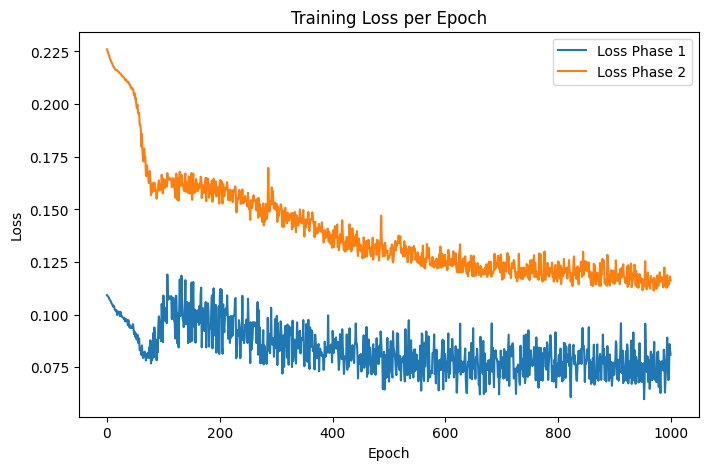

In [ ]:
# Plot the training losses for both phases
import matplotlib.pyplot as plt

loss_phase1_log = [l[0] for l in loss_log]
loss_phase2_log = [l[1] for l in loss_log]

plt.figure(figsize=(8, 5))
plt.plot(loss_phase1_log, label='Loss Phase 1')
plt.plot(loss_phase2_log, label='Loss Phase 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import glob

model.eval()  # Set the model to evaluation mode
# Create a folder to save images
output_folder = "frames_pca"
os.makedirs(output_folder, exist_ok=True)

# Initialize the seed tensor
inference_seed = seed_tensor.clone().to(device)

# Run the simulation and save images every 10 steps
for i in range(150):
    with torch.no_grad():
        inference_seed = model(inference_seed)
    
    # Extract all channels and compute the top 3 principal components
    channels = inference_seed[0].detach().cpu().numpy().transpose(1, 2, 0).reshape(-1, inference_seed.shape[1])  # Flatten spatial dimensions
    pca = PCA(n_components=3)
    pcs = pca.fit_transform(channels).reshape(inference_seed.shape[2], inference_seed.shape[3], 3)  # Reshape back to spatial dimensions
    
    # Normalize the top 3 PCs to [0, 1] for visualization
    pcs_normalized = (pcs - pcs.min(axis=(0, 1), keepdims=True)) / (pcs.max(axis=(0, 1), keepdims=True) - pcs.min(axis=(0, 1), keepdims=True) + 1e-8)
    
    # Apply threshold to determine "dead" pixels (alpha channel or other criteria)
    alive_mask = inference_seed[0, -1].detach().cpu().numpy() >= 0.1  # Assuming the last channel is the alpha channel
    pcs_normalized[~alive_mask] = [0, 0, 0]  # Set dead pixels to black
    
    # Use the top 3 PCs as the RGB representation
    rgb = pcs_normalized
    
    # Save the frame
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"Step {i}")
    plt.savefig(os.path.join(output_folder, f"frame_{i:03d}.png"), bbox_inches="tight")
    plt.close()

# Create and save the GIF
input_folder = "frames_pca"
output_gif = "pca_dynamic.gif"

# Get all image files in the folder, sorted by filename
image_files = sorted(glob.glob(os.path.join(input_folder, "frame_*.png")))

# Load images into a list
frames = [Image.open(img) for img in image_files]

# Create and save the GIF
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=125,  # Duration between frames in milliseconds
    loop=0         # Loop forever (set to 1 for looping once)
)

In [ ]:
torch.save(model.state_dict(), "dynamic_model.pth")